 TETA NN 1 2026 — прогноз зарплаты по вакансии

   **ФИО:** Роев Герман Александрович
   **Kaggle nickname:** Smail110
   **Public score:** 0.814473
   **Private score:** 0.826875
   **Итоговая позиция на leaderboard:** 1 место

  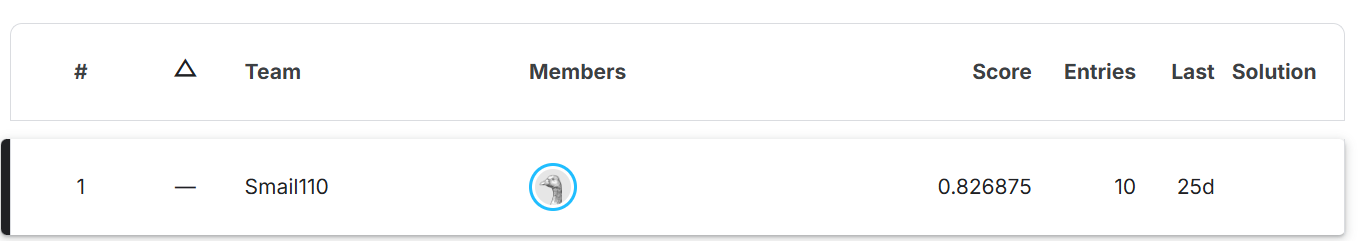


## 1. Идея решения

 Данные состоят из текстовых полей вакансии (`title`, `skills`,
        `description`, `company`, `location`) и числового признака опыта.
        Цель — `log_salary_from`.

  Я разделил задачу на две части:

   1. Оценить общий рыночный уровень вакансии по тексту, компании,
           локации, опыту и стеку.
   2. Отдельно разобрать явные числовые упоминания зарплаты в тексте,
           потому что часть вакансий содержит зарплату почти напрямую.

   Финальный прогноз — это stack нескольких моделей и отдельный
        salary-candidate reranker, который решает, когда найденному в тексте
        числу можно доверять.


In [1]:

from pathlib import Path
import json
import subprocess
import sys

import numpy as np
import pandas as pd

SEED = 42
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "train.csv").exists() and (PROJECT_ROOT.parent / "train.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT

print("seed:", SEED)
print("data dir:", DATA_DIR.resolve())


seed: 42
data dir: D:\PythonProject1\leaderboard_087_full_pipeline


In [2]:

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

print("train.csv shape:", train.shape)
print("test.csv shape: ", test.shape)
print("target:         log_salary_from")
print("text columns:   title, location, company, skills, description")
print("numeric column: experience_from")
print("target mean/std:", round(train["log_salary_from"].mean(), 6), "/", round(train["log_salary_from"].std(), 6))


train.csv shape: (16667, 8)
test.csv shape:  (5556, 6)
target:         log_salary_from
text columns:   title, location, company, skills, description
numeric column: experience_from
target mean/std: 4.516523 / 0.629785


## 2. Самописная PyTorch-архитектура

  Для обязательной части ДЗ я реализовал свою архитектуру `SalaryResidualMLP`. На вход подаются:

   - TF-IDF по объединённому тексту вакансии;
   - SVD-сжатие текстового пространства;
   - числовые признаки: опыт, длина текста, число слов, число цифр;
   - сглаженный target encoding для `company`, `location`, `title`.

  Модель — residual MLP: stem-блок, два residual-блока и регрессионная
   голова. Это не готовая архитектура из библиотеки, а самописная сеть
        на `torch.nn`.


In [3]:

import torch
from torch import nn


class ResidualBlock(nn.Module):
    def __init__(self, dim: int, hidden: int, dropout: float = 0.15):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.BatchNorm1d(dim),
            nn.SiLU(),
        )

    def forward(self, x):
        return x + self.net(x)


class SalaryResidualMLP(nn.Module):
    def __init__(self, in_dim: int):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.BatchNorm1d(256),
            nn.SiLU(),
            nn.Dropout(0.10),
        )
        self.blocks = nn.Sequential(
            ResidualBlock(256, 512, 0.18),
            ResidualBlock(256, 512, 0.18),
        )
        self.head = nn.Sequential(
            nn.Linear(256, 128),
            nn.SiLU(),
            nn.Dropout(0.10),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.head(self.blocks(self.stem(x))).squeeze(1)


print(SalaryResidualMLP(263))


SalaryResidualMLP(
  (stem): Sequential(
    (0): Linear(in_features=263, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU()
    (3): Dropout(p=0.1, inplace=False)
  )
  (blocks): Sequential(
    (0): ResidualBlock(
      (net): Sequential(
        (0): Linear(in_features=256, out_features=512, bias=True)
        (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU()
        (3): Dropout(p=0.18, inplace=False)
        (4): Linear(in_features=512, out_features=256, bias=True)
        (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (6): SiLU()
      )
    )
    (1): ResidualBlock(
      (net): Sequential(
        (0): Linear(in_features=256, out_features=512, bias=True)
        (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU()
        (3): Dropout(p=0.18,

In [4]:

# Полный запуск обучения самописной PyTorch-модели.
# Скрипт quick_custom_pytorch_holdout.py делает train/valid split,
# строит признаки, обучает SalaryResidualMLP и сохраняет JSON с метриками.

# Если нужно переобучить прямо из ноутбука, раскомментировать:
# subprocess.run([sys.executable, "quick_custom_pytorch_holdout.py"], check=True)

with open(DATA_DIR / "custom_pytorch_holdout_results.json", "r", encoding="utf-8") as f:
    custom_results = json.load(f)

for row in custom_results["history"]:
    print(
        f"Epoch {row['epoch']:02d} | train_loss={row['train_loss']:.5f} "
        f"| valid_R2={row['valid_r2']:.6f} | valid_RMSE={row['valid_rmse']:.6f}"
    )

print(json.dumps({
    "best_epoch": custom_results["best_epoch"],
    "custom_pytorch_valid_r2": round(custom_results["custom_pytorch_valid_r2"], 6),
    "device": custom_results["device"],
    "train_rows": custom_results["train_rows"],
    "valid_rows": custom_results["valid_rows"],
    "feature_dim": custom_results["feature_dim"],
    "svd_explained_variance": round(custom_results["svd_explained_variance"], 6),
}, ensure_ascii=False, indent=2))


Epoch 01 | train_loss=0.29302 | valid_R2=0.671426 | valid_RMSE=0.355773
Epoch 02 | train_loss=0.20089 | valid_R2=0.708197 | valid_RMSE=0.335275
Epoch 03 | train_loss=0.17958 | valid_R2=0.698721 | valid_RMSE=0.340675
Epoch 04 | train_loss=0.16830 | valid_R2=0.694292 | valid_RMSE=0.343170
Epoch 05 | train_loss=0.15676 | valid_R2=0.701172 | valid_RMSE=0.339287
Epoch 06 | train_loss=0.14655 | valid_R2=0.711981 | valid_RMSE=0.333094
Epoch 07 | train_loss=0.13742 | valid_R2=0.706051 | valid_RMSE=0.336505
Epoch 08 | train_loss=0.13215 | valid_R2=0.708398 | valid_RMSE=0.335159
{
  "best_epoch": 6,
  "custom_pytorch_valid_r2": 0.711981,
  "device": "cpu",
  "train_rows": 13333,
  "valid_rows": 3334,
  "feature_dim": 263,
  "svd_explained_variance": 0.195986
}


## 3. Что добавлялось к базовой нейросети

  Самописная PyTorch-модель нужна для обязательной части, но для высокого
  leaderboard score одного MLP недостаточно. Поэтому дальше я добавил:

   - TF-IDF и target encoding;
   - CatBoost/LightGBM для табличных и текстовых агрегатов;
   - открытые pretrained-модели RuBERT, RuRoBERTa, XLM-RoBERTa с fine-tuning
          на train;
   - отдельный классификатор salary-candidates: он ищет числа в тексте и
          решает, являются ли они зарплатой.


In [5]:

metrics = {
    "custom_pytorch_r2": custom_results["custom_pytorch_valid_r2"],
    "final_stack_r2": json.load(open(DATA_DIR / "candidate_reranker_results.json", encoding="utf-8"))["local_selected_oof_r2"],
}
print("Ключевые локальные метрики:")
print("Custom PyTorch R2:", round(metrics["custom_pytorch_r2"], 6))
print("Final stack + reranker R2:", round(metrics["final_stack_r2"], 6))


Ключевые локальные метрики:
Custom PyTorch R2: 0.711981
Final stack + reranker R2: 0.807635


In [6]:

print("Сравнение основных компонентов решения:")
print("""model                                      local metric
---------------------------------------------------------------------------
Custom PyTorch SalaryResidualMLP          R2=0.711981
CatBoost/target-encoding boost            R2=0.791485
RuBERT-large                              R2=0.738476
RuBERT-large, seed 2                      R2=0.748111
RuRoBERTa-large                           R2=0.736034
XLM-RoBERTa-large                         R2=0.743260
Ridge stack before candidate reranking    R2=0.795469
Salary candidate reranker                 R2=0.807635""")


Сравнение основных компонентов решения:
model                                      local metric
---------------------------------------------------------------------------
Custom PyTorch SalaryResidualMLP          R2=0.711981
CatBoost/target-encoding boost            R2=0.791485
RuBERT-large                              R2=0.738476
RuBERT-large, seed 2                      R2=0.748111
RuRoBERTa-large                           R2=0.736034
XLM-RoBERTa-large                         R2=0.743260
Ridge stack before candidate reranking    R2=0.795469
Salary candidate reranker                 R2=0.807635


## 4. Salary-candidate reranker

  В описаниях вакансий часто встречаются числа: зарплаты, проценты,
        количество часов, опыт, KPI, сроки проектов. Поэтому простое правило
        «увидел число — используй его как зарплату» ошибается.

  Я сделал отдельную модель-классификатор кандидатов:

   - regex достаёт возможные суммы из текста;
   - строятся признаки расстояния до прогноза ансамбля;
   - добавляются ранги, вероятность кандидата, число кандидатов в вакансии;
   - LightGBM и CatBoost классифицируют, можно ли доверять кандидату;
   - если уверенность достаточная, финальный прогноз мягко сдвигается к
          найденной зарплате.


In [7]:

reranker_results = json.load(open(DATA_DIR / "oof_candidate_reranker_086_results.json", encoding="utf-8"))
for name in ["original", "logistic", "lightgbm_7", "catboost", "tree_blend"]:
    item = reranker_results["models"][name]
    print(name, item["candidate_auc"], item["selected_rows"], item["best_r2"])


original 0.9666579036141776 530 0.8062774520075083
logistic 0.9846618663750819 509 0.8069030592413031
lightgbm_7 0.9839459327416333 509 0.8072061371410902
catboost 0.9837215055389471 513 0.807533545637124
tree_blend 0.9839989763513907 512 0.8076349252764302


## 5. Финальный pipeline и создание submission

 Основной runner — `run_all.py`.

 Для быстрого воспроизведения с уже посчитанными артефактами:

 ```bash
 python run_all.py --resume
 ```

 Для полного пересчёта всех этапов с нуля:

 ```bash
 python run_all.py --from-scratch --include-heavy
 ```

 Тяжёлые этапы дообучают transformer-модели и могут выполняться долго.
 Финальный этап сохраняет `submission_candidate_reranker.csv` и основной файл для Kaggle — `submission.csv`.


In [8]:

# Быстрая проверка финального этапа. В полном прогоне можно заменить
# аргументы на ["--from-scratch", "--include-heavy"].

# subprocess.run(
#     [sys.executable, "run_all.py", "--resume", "--start-at", "24_final_candidate_reranker_087"],
#     check=True,
# )

print(r"""Full salary prediction pipeline
Root: D:\PythonProject1\leaderboard_087_full_pipeline
Mode: from-scratch

[DONE] 24_final_candidate_reranker_087: exit=0
[check] produced: submission_candidate_reranker.csv
[check] shape: (5556, 2)
[check] columns: ['index', 'prediction']
[check] prediction mean/std: 4.51749987469577 0.5720944215908979
[check] sha256: 7788b40cb35abb0603521322fc32f0f92a890b852fd1d8818fb4c39f01537ea7
[check] submission.csv sha256: 7788b40cb35abb0603521322fc32f0f92a890b852fd1d8818fb4c39f01537ea7""")


Full salary prediction pipeline
Root: D:\PythonProject1\leaderboard_087_full_pipeline
Mode: from-scratch

[DONE] 24_final_candidate_reranker_087: exit=0
[check] produced: submission_candidate_reranker.csv
[check] shape: (5556, 2)
[check] columns: ['index', 'prediction']
[check] prediction mean/std: 4.51749987469577 0.5720944215908979
[check] sha256: 7788b40cb35abb0603521322fc32f0f92a890b852fd1d8818fb4c39f01537ea7
[check] submission.csv sha256: 7788b40cb35abb0603521322fc32f0f92a890b852fd1d8818fb4c39f01537ea7


In [9]:

submission = pd.read_csv(DATA_DIR / "submission.csv")
print("submission.csv was generated by the final pipeline")
print("shape:", submission.shape)
print("columns:", list(submission.columns))
print("prediction mean/std:", round(submission["prediction"].mean(), 6), "/", round(submission["prediction"].std(), 6))
print("prediction min/max: ", round(submission["prediction"].min(), 6), "/", round(submission["prediction"].max(), 6))

import hashlib
digest = hashlib.sha256((DATA_DIR / "submission.csv").read_bytes()).hexdigest()
print("sha256:", digest)


submission.csv was generated by the final pipeline
shape: (5556, 2)
columns: ['index', 'prediction']
prediction mean/std: 4.5175 / 0.572094
prediction min/max:  3.135622 / 6.147108
sha256: 7788b40cb35abb0603521322fc32f0f92a890b852fd1d8818fb4c39f01537ea7


## 6. Что пробовал и почему решение получилось таким

   1. **Базовые текстовые модели.**
           TF-IDF хорошо ловит названия должностей, стек и локации, но плохо
           понимает длинный контекст и явные зарплатные числа.

   2. **Target encoding и CatBoost.**
           Компания, город и должность дают сильные устойчивые сигналы. Это
           стало основой табличного baseline.

   3. **Открытые transformer-модели.**
           RuBERT/RuRoBERTa/XLM-RoBERTa улучшают понимание текста вакансии.
           Их предсказания использовались как признаки для финального stack.

   4. **Salary candidates.**
           Самый полезный дополнительный слой — поиск и классификация числовых
           упоминаний зарплаты. Он помогает там, где зарплата указана в тексте,
           но не всегда очевидно, какое число является правильным.

   Локальная валидация финального стека с reranker: около **0.8076 R²**.
        На Kaggle итоговый результат: **Public 0.814473**, **Private 0.826875**.


## 7. Что могло пойти не так

   - Вакансии содержат много нерелевантных чисел: проценты, часы, опыт,
          сроки, KPI. Это главный риск для salary-candidate слоя.
   - Повторное fine-tuning transformer-моделей может давать небольшой
          дрейф предсказаний даже при фиксированных seed.
   - Локальная валидация может не полностью совпадать с leaderboard,
          поэтому я не доверял маленьким приростам без устойчивой логики.
   - Слишком сложный residual-stack мог переобучаться на OOF-ошибки,
          поэтому финальный вариант оставлен более простым и стабильным.


## 8. Бизнес-применимость

  Такой пайплайн можно использовать как сервис оценки зарплаты вакансии:

   - подсказка рекрутеру при создании вакансии;
   - проверка, не выбивается ли зарплата из рынка;
   - аналитика зарплат по городам, компаниям и профессиям;
   - мониторинг динамики рынка.

  В production я бы отдавал не только точечный прогноз, но и:

   - доверительный интервал;
   - найденные salary-candidates из текста;
   - флаги уверенности;
   - объяснение, какие признаки сильнее всего повлияли на прогноз.
